# 00 — The algorithm, end to end

The whole thing in one notebook: **numpy only, no repo imports, about 40 lines of algorithm.**
Short explanations, then it acquires a real GPS signal.

Everything else in `notebooks/` and `sim/` is *measurement* of this algorithm — how well it
works, what it costs, how it compares. This notebook is just the algorithm.

**The problem.** A GPS satellite transmits a 1023-chip code repeating every 1 ms, buried ~25 dB
below the noise. Three things are unknown: **which satellite** (32 options), **the code phase**
(1023 options), and **the Doppler shift** (±10 kHz). Find them.

**The idea.** Store each (satellite, Doppler) hypothesis as a row of bits in a CAM. Quantize
the incoming signal to bits. The CAM compares the incoming bits against every row at once and
reports, for each row, a single bit: *is the Hamming distance below $\tau$?* No multipliers, no
correlator, no magnitudes — just bit comparisons and a threshold.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

FS   = 2.046e6      # sampling rate: 2 samples per chip
NS   = 2046         # samples in one 1 ms code period
CL   = 1023         # chips in the C/A code
L1   = 1575.42e6    # carrier frequency

---
## 1. The code

Each satellite has its own 1023-chip Gold code, generated by two 10-stage shift registers.
The codes are near-orthogonal: a code correlates to 1023 with itself and at most 65 with
anything else, including shifted copies of itself. That is what makes both the satellite and
the code phase findable.

In [2]:
# IS-GPS-200 Table 3-Ia: which G2 stages are XOR-ed, per satellite.
G2 = {1:(2,6),  2:(3,7),  3:(4,8),  4:(5,9),  5:(1,9),  6:(2,10), 7:(1,8),  8:(2,9),
      9:(3,10),10:(2,3), 11:(3,4), 12:(5,6), 13:(6,7), 14:(7,8), 15:(8,9), 16:(9,10),
      17:(1,4),18:(2,5), 19:(3,6), 20:(4,7), 21:(5,8), 22:(6,9), 23:(1,3), 24:(4,6),
      25:(5,7),26:(6,8), 27:(7,9), 28:(8,10),29:(1,6), 30:(2,7), 31:(3,8), 32:(4,9)}

def ca_code(prn):
    """The satellite's 1023-chip code, as +1/-1."""
    t1, t2 = G2[prn]
    g1 = np.ones(10, np.uint8); g2 = np.ones(10, np.uint8)
    out = np.empty(CL, np.uint8)
    for i in range(CL):
        out[i] = g1[9] ^ g2[t1-1] ^ g2[t2-1]
        f1 = g1[2] ^ g1[9]
        f2 = g2[1] ^ g2[2] ^ g2[5] ^ g2[7] ^ g2[8] ^ g2[9]
        g1[1:] = g1[:9]; g1[0] = f1
        g2[1:] = g2[:9]; g2[0] = f2
    return 1.0 - 2.0 * out

c = ca_code(7)
print("PRN 7 code:", c[:12].astype(int), "...")
print("correlation with itself      :", int(c @ c))
print("shifted by 1 chip            :", int(c @ np.roll(c, 1)))
print("with a different satellite   :", int(c @ ca_code(19)))

PRN 7 code: [-1  1  1 -1  1 -1 -1  1  1 -1 -1 -1] ...
correlation with itself      : 1023
shifted by 1 chip            : 63
with a different satellite   : -1


---
## 2. The received signal

The code, sampled at 2 samples/chip starting from an unknown code phase, spun by an unknown
Doppler and carrier phase, plus noise:

$$ r[n] = A\,c[n-\tau]\,e^{\,j(2\pi f_d n/f_s + \theta_0)} + w[n] $$

Noise is fixed at unit variance per rail and the *signal* is scaled to hit the requested
C/N0 — that keeps the quantizer's operating point fixed.

In [3]:
def replica(prn, fd, n, code_phase, theta):
    """Noiseless unit-amplitude signal: the code, Doppler-shifted, at a given carrier phase."""
    chips_per_sample = (1.023e6 / FS) * (1 + fd / L1)          # code Doppler too
    idx = code_phase + chips_per_sample * np.arange(n)
    chips = ca_code(prn)[np.floor(idx).astype(np.int64) % CL]
    return chips * np.exp(1j * (2 * np.pi * fd * np.arange(n) / FS + theta))

def receive(prn, cn0_dbhz, fd, n, code_phase, rng):
    """One realization of the received signal at a given C/N0."""
    A = np.sqrt(2 * 10 ** (cn0_dbhz / 10) / FS)
    s = A * replica(prn, fd, n, code_phase, rng.uniform(0, 2 * np.pi))
    return s + rng.normal(0, 1, n) + 1j * rng.normal(0, 1, n)

rng = np.random.default_rng(0)
demo = receive(7, 48.0, 1500.0, NS, 300.0, rng)
print(f"signal amplitude A = {np.sqrt(2*10**4.8/FS):.4f}  vs  noise std 1.0")
print("-> the signal is far below the noise; nothing is visible in the time domain.")

signal amplitude A = 0.2483  vs  noise std 1.0
-> the signal is far below the noise; nothing is visible in the time domain.


---
## 3. Signal to bits

The front end keeps only the **sign** of each rail. One bit per rail, two bits per sample,
laid out `[I0 Q0 I1 Q1 ...]`. A 1 ms dwell becomes a 4092-bit key.

This throws away the magnitude, which costs 1.96 dB — the standard price of a 1-bit GNSS
front end, paid by conventional receivers too.

In [4]:
def to_key(x):
    """Complex samples -> flat bit vector. Bit = 1 means negative."""
    return np.stack([x.real < 0, x.imag < 0], -1).ravel()

key = to_key(demo)
print(f"key: {key[:12].astype(int)} ...   length {len(key)} bits = {NS} samples x 2 rails")

key: [1 0 0 0 1 1 1 0 0 0 0 1] ...   length 4092 bits = 2046 samples x 2 rails


---
## 4. The codebook: one row per hypothesis

A row is the *noiseless* signal for one (satellite, Doppler) pair, put through the same sign
mapping. Code phase is **not** stored — it is handled by sliding the key (§7).

Rows are built at $\theta = 45°$ so that both the I and Q rails carry the code. At $\theta=0$
the signal is purely real and the row's Q rail would be a constant, wasting half the
comparison.

Doppler bins are spaced $1/(2T) = 500$ Hz, so ±10 kHz needs 41 rows per satellite.

In [5]:
PRNS = [1, 7, 19]                       # a 3-satellite search, to keep this quick
GRID = np.arange(-20, 21) * 500.0       # +-10 kHz in 500 Hz steps

rows = np.array([to_key(replica(p, f, NS, 0.0, np.pi/4)) for p in PRNS for f in GRID])
tags = [(p, f) for p in PRNS for f in GRID]
W = rows.shape[1]

print(f"codebook: {rows.shape[0]} rows x {W} bits "
      f"= {len(PRNS)} satellites x {len(GRID)} Doppler bins")
print(f"stored state: {rows.size/1e6:.2f} Mbit")

codebook: 123 rows x 4092 bits = 3 satellites x 41 Doppler bins
stored state: 0.50 Mbit


---
## 5. The CAM

The entire readout primitive. It returns **one boolean per row** — never a distance, never a
ranking. That restriction is the whole point: it is what an analog match line can deliver in a
single cycle.

In [6]:
def cam_query(rows, key, tau):
    """The only readout: does each row match within tau bits?"""
    return (rows != key).sum(axis=1) <= tau

fired = cam_query(rows, key, tau=1900)
print(f"rows fired: {np.flatnonzero(fired)}  (out of {len(rows)})")
print("(nothing yet -- the code phase is still wrong, and so is the carrier phase)")

rows fired: []  (out of 123)
(nothing yet -- the code phase is still wrong, and so is the carrier phase)


---
## 6. The free rotation

The carrier phase $\theta_0$ is unknown and continuous. A conventional receiver removes it by
taking a magnitude $|z|^2$ — but a CAM has no squarer.

Instead: multiplying a sample by $j$ is $(I,Q) \to (-Q, I)$, which on sign bits is a **wire
swap and an inversion**. Exact, free, no arithmetic. So we try all four 90° rotations and take
whichever fires. The residual phase error is then at most 45°, costing 3 dB — and never blind.

Without this the detector does not work at all: a random $\theta_0$ averages the correlation
to zero.

In [7]:
def rotate(key, q):
    """Rotate a key by q*90 degrees: (I,Q) -> (-Q,I), exactly."""
    v = key.reshape(-1, 2)
    for _ in range(q % 4):
        v = np.stack([~v[:, 1], v[:, 0]], -1)
    return v.ravel()

x = np.array([0.7 + 0.2j])
print("original         :", to_key(x).astype(int))
print("rotated 90 deg   :", rotate(to_key(x), 1).astype(int))
print("quantized j*x    :", to_key(1j * x).astype(int), " <- identical, so the rotation is exact")

original         : [0 0]
rotated 90 deg   : [1 0]
quantized j*x    : [1 0]  <- identical, so the rotation is exact


---
## 7. The search

Now put it together. For each code phase, form the key and query the CAM under all four
rotations; a cell fires if any rotation fires.

One detail that matters: the key is taken from a **2 ms sliding buffer**, not by wrapping a
1 ms one. Wrapping would splice together samples whose carrier phase differs by
$2\pi f_d \cdot 1\text{ms}$ — 1.5 whole cycles at 1500 Hz — putting a phase discontinuity in
the middle of the key.

(Below we compute the distances and threshold them in one step, purely so the plot can show
the surface. The hardware only ever sees the thresholded bit.)

In [8]:
SHIFTS = np.arange(0, NS, 2)            # chip-spaced code phases
ROWS_PM = (1.0 - 2.0 * rows).astype(np.float32)     # rows as +-1, for a fast batch compare

def search(samples_2ms):
    """Hamming distance for every (code phase, row), minimised over the 4 free rotations."""
    best = np.full((len(SHIFTS), len(rows)), W, np.float32)
    for q in range(4):
        K = np.array([rotate(to_key(samples_2ms[s:s + NS]), q) for s in SHIFTS])
        # in the +-1 domain,  hamming = (W - dot) / 2
        D = (W - (1.0 - 2.0 * K).astype(np.float32) @ ROWS_PM.T) / 2
        np.minimum(best, D, out=best)
    return best.astype(int)

print(f"{len(SHIFTS)} code phases x {len(rows)} rows = {len(SHIFTS)*len(rows):,} cells to search")

1023 code phases x 123 rows = 125,829 cells to search


---
## 8. Run it

A signal from **PRN 7**, at code phase **300 chips**, Doppler **+1500 Hz**, at 48 dB-Hz.
The algorithm is not told any of that.

In [9]:
TRUTH = dict(prn=7, code_phase=300.0, fd=1500.0)
r = receive(TRUTH["prn"], 48.0, TRUTH["fd"], 2 * NS, TRUTH["code_phase"],
            np.random.default_rng(0))

D = search(r)
TAU = 1880

print(f"chance distance is W/2 = {W//2}; the closest cell is at {D.min()}\n")
print("cells that fired:")
for a, b in np.argwhere(D <= TAU):
    print(f"   code phase {SHIFTS[a]/2:6.1f} chips   PRN {tags[b][0]:2d}   "
          f"Doppler {tags[b][1]:+7.0f} Hz   (distance {D[a,b]})")
print(f"\ntruth: code phase {TRUTH['code_phase']:.1f} chips, PRN {TRUTH['prn']}, "
      f"Doppler {TRUTH['fd']:+.0f} Hz")

chance distance is W/2 = 2046; the closest cell is at 1764

cells that fired:
   code phase  723.0 chips   PRN  7   Doppler   +1500 Hz   (distance 1764)
   code phase  723.0 chips   PRN  7   Doppler   +2000 Hz   (distance 1851)

truth: code phase 300.0 chips, PRN 7, Doppler +1500 Hz


Note the expected code phase is **723 chips**, not 300: the signal *starts* at chip 300, so we
have to advance $1023 - 300 = 723$ chips to line the buffer up with chip 0 of the code, which
is where the rows begin.

Two cells fire, at the same code phase and satellite, one Doppler bin apart. That is normal and
expected — the bins are spaced at half the correlation null, so a true signal always partly
matches its neighbour. **A tight cluster is the signature of a detection**; the tracking loop
takes it from here and refines. Scattered isolated fires would be the false alarms.

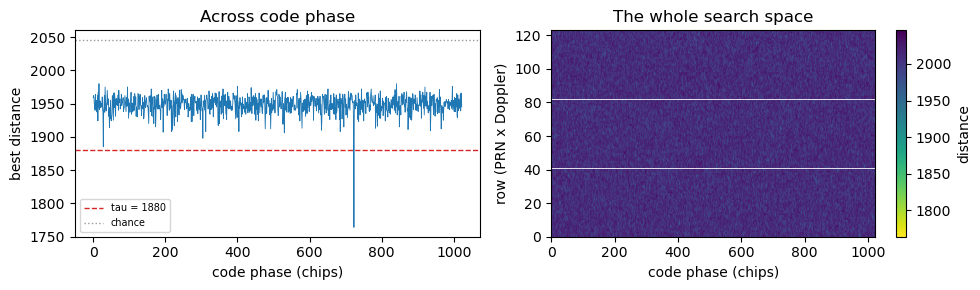

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(SHIFTS / 2, D.min(axis=1), lw=0.6)
axes[0].axhline(TAU, color="C3", ls="--", lw=1, label=f"tau = {TAU}")
axes[0].axhline(W // 2, color="0.6", ls=":", lw=1, label="chance")
axes[0].set(xlabel="code phase (chips)", ylabel="best distance", title="Across code phase")
axes[0].legend(fontsize=7)

im = axes[1].imshow(D.T, aspect="auto", origin="lower", cmap="viridis_r",
                    extent=[0, CL, 0, len(rows)])
for i in range(1, len(PRNS)):
    axes[1].axhline(i * len(GRID), color="w", lw=0.6)
axes[1].set(xlabel="code phase (chips)", ylabel="row (PRN x Doppler)",
            title="The whole search space")
plt.colorbar(im, ax=axes[1], label="distance")
plt.tight_layout(); plt.show()

---
## 9. Weak signals: accumulate

At 48 dB-Hz one dwell was enough. At a realistic 38 dB-Hz it is not — for *any* receiver,
including a full-precision one. The fix is to repeat and **count fires**, which a boolean
readout does naturally: no magnitudes to add, just a counter per cell.

Declare a detection where the count reaches $k$.

In [11]:
rng = np.random.default_rng(7)
acc = np.zeros((len(SHIFTS), len(rows)), int)
truth_cell = (int(np.flatnonzero(SHIFTS == (CL - 300) * 2)[0]), tags.index((7, 1500.0)))

print(f"{'dwells':>7} {'count at truth':>15} {'best elsewhere':>16}")
for m in range(1, 13):
    acc += search(receive(7, 38.0, 1500.0, 2 * NS, 300.0, rng)) <= 1950
    other = acc.copy(); other[truth_cell] = -1
    if m in (1, 3, 6, 9, 12):
        print(f"{m:>7} {acc[truth_cell]:>15} {other.max():>16}")

k = 4
hits = np.argwhere(acc >= k)
print(f"\nafter 12 dwells, cells reaching k={k}:")
for a, b in hits:
    print(f"   code phase {SHIFTS[a]/2:6.1f} chips   PRN {tags[b][0]:2d}   Doppler {tags[b][1]:+7.0f} Hz")

 dwells  count at truth   best elsewhere
      1               1                1
      3               1                3
      6               1                3
      9               4                3
     12               4                3

after 12 dwells, cells reaching k=4:
   code phase  723.0 chips   PRN  7   Doppler   +1500 Hz


The correct cell separates from the background as the count accumulates. $\tau$ and $k$ are
not guesses — they are chosen so that the false-alarm rate summed over all 125,829 cells stays
under a budget (1% here). Notebook 07 does that sizing properly.

---
## 10. The full search: all 32 satellites

The demo above searched 3 satellites. A real cold start searches all 32 — 1312 rows and, at
half-chip resolution, **2.7 million cells**. Same algorithm; it just needs slightly better
bookkeeping to run quickly in numpy.

Two shortcuts, neither of which changes what is computed:

1. **Sliding window.** Sign-quantize the 2 ms buffer once; every code phase is then a window
   into the same bit array, so we never re-quantize.
2. **Rotating by 180° is free.** It complements every bit, so $d_{180} = W - d_0$ and
   $d_{270} = W - d_{90}$. Only **two** of the four rotations need computing.

In [12]:
from numpy.lib.stride_tricks import sliding_window_view
from functools import lru_cache
import time

ca_code_fast = lru_cache(None)(ca_code)          # 32 codes, each computed once

PRNS32 = list(range(1, 33))

def build_codebook(prns, grid):
    """One row per (satellite, Doppler), same as section 4 but for all 32."""
    rows, tags = [], []
    for p in prns:
        code = ca_code_fast(p)
        for f in grid:
            idx = (1.023e6 / FS) * (1 + f / L1) * np.arange(NS)
            chips = code[np.floor(idx).astype(np.int64) % CL]
            rows.append(to_key(chips * np.exp(1j*(2*np.pi*f*np.arange(NS)/FS + np.pi/4))))
            tags.append((p, f))
    return np.array(rows), tags

ROWS32, TAGS32 = build_codebook(PRNS32, GRID)
RPM32 = (1.0 - 2.0 * ROWS32).astype(np.float32)
TAG_PRN = np.array([t[0] for t in TAGS32])
TAG_FD  = np.array([t[1] for t in TAGS32])
HALF = np.arange(NS)                              # half-chip code phases

print(f"codebook: {ROWS32.shape[0]} rows = {len(PRNS32)} satellites x {len(GRID)} Doppler bins")
print(f"stored  : {ROWS32.size/1e6:.2f} Mbit")
print(f"search  : {len(HALF)} code phases x {ROWS32.shape[0]} rows = {len(HALF)*ROWS32.shape[0]:,} cells")

codebook: 1312 rows = 32 satellites x 41 Doppler bins
stored  : 5.37 Mbit
search  : 2046 code phases x 1312 rows = 2,684,352 cells


In [13]:
def search32(samples_2ms):
    """Section 7's algorithm, over all 32 satellites at half-chip resolution."""
    b = np.stack([samples_2ms.real < 0, samples_2ms.imag < 0], -1)
    best = None
    for q in (0, 1):                                        # q = 2, 3 come free below
        v = b if q == 0 else np.stack([~b[:, 1], b[:, 0]], -1)
        K = sliding_window_view(v.reshape(-1), W)[::2][:len(HALF)]
        D = (W - (1.0 - 2.0 * K.astype(np.float32)) @ RPM32.T) / 2
        D = np.minimum(D, W - D)                            # rotating 180 deg = complement
        best = D if best is None else np.minimum(best, D)
    return best

truth = dict(prn=23, code_phase=811.3, fd=-4237.0)          # none of these on a grid point
t0 = time.time()
r32 = receive(truth["prn"], 50.0, truth["fd"], 2*NS, truth["code_phase"], np.random.default_rng(3))
D32 = search32(r32)
print(f"one full 32-satellite search: {time.time()-t0:.2f}s\n")

# The CAM does NOT report which cell is closest -- only which cells cross tau.
TAU32_DEMO = 1880
print(f"cells firing at tau = {TAU32_DEMO} (this is all the array tells us):")
for a, b in np.argwhere(D32 <= TAU32_DEMO):
    print(f"   PRN {TAG_PRN[b]:2d}, Doppler {TAG_FD[b]:+7.0f} Hz, code phase {HALF[a]/2:7.1f} chips")
print(f"\ntruth: PRN {truth['prn']:2d}, Doppler {truth['fd']:+7.0f} Hz, "
      f"code phase {(CL-truth['code_phase'])%CL:7.1f} chips")

one full 32-satellite search: 0.36s

cells firing at tau = 1880 (this is all the array tells us):
   PRN 23, Doppler   -4500 Hz, code phase   211.5 chips
   PRN 23, Doppler   -4000 Hz, code phase   211.5 chips
   PRN  5, Doppler   -2500 Hz, code phase   535.0 chips
   PRN 24, Doppler  +10000 Hz, code phase   652.5 chips

truth: PRN 23, Doppler   -4237 Hz, code phase   211.7 chips


It picks the right satellite out of 32, with Doppler inside one bin and code phase inside half
a chip — even though the true Doppler and code phase both sit *between* grid points. That
straddling is realistic, and it costs signal: up to 0.25 chip and 250 Hz, together worth
about 3 dB.

---
## 11. Does it work in general? A Monte Carlo

One lucky signal proves nothing. Now randomize **everything** and sweep C/N0.

| per trial | drawn from |
|---|---|
| satellite | uniform over all 32 |
| code phase | uniform continuous over 1023 chips (not a grid point) |
| Doppler | uniform continuous over ±10 kHz (not a bin centre) |
| carrier phase $\theta_0$ | uniform over $[0, 2\pi)$, redrawn every dwell |
| amplitude | set by the C/N0 of the sweep point |

**Choosing $\tau$ and $k$.** $\tau$ is loose enough that a true cell usually fires; $k$ is then
the smallest fire count that keeps the false-alarm probability *summed over all 2.7 M cells*
under 1%. Watch what falls out of that: at this $\tau$, **$M=1$ and $M=2$ cannot meet the
budget at any $k$.** With 2.7 M chances to be wrong, one or two looks are not enough evidence
no matter where the threshold goes.

> **What the decision rule may and may not use.** The CAM never reports *which* row is closest
> — only which rows crossed $\tau$. So the detector below declares **every cell whose count
> reaches $k$**, and never ranks them. That is exactly what
> [`segment.detect`](../sim/gps/segment.py) returns.
>
> This is not a pedantic distinction. Picking the `argmin` over distances, or even the `argmax`
> over fire counts, would quietly launder a false alarm into a success: if a wrong cell also
> crosses $k$ but the true cell crosses "more", ranking hides the error that a real receiver
> would have to live with. So a trial can declare several cells — and we count the true ones
> and the false ones separately.

In [14]:
from scipy.stats import binom

NCELLS = len(HALF) * ROWS32.shape[0]
TAU32  = 1930

rng = np.random.default_rng(11)
noise_D = search32(rng.normal(0,1,2*NS) + 1j*rng.normal(0,1,2*NS))
p0 = (noise_D <= TAU32).mean()

print(f"tau = {TAU32}  ->  p0 = {p0:.2e}   (measured on noise alone)")
print(f"budget: 1% spread over {NCELLS:,} cells = {0.01/NCELLS:.2e} per cell\n")
K_OF_M = {}
for M in [1, 2, 4, 8]:
    k = next((kk for kk in range(1, M+1) if binom.sf(kk-1, M, p0)*NCELLS <= 0.01), None)
    print(f"  M={M}: k = {k}" + ("   <-- no threshold meets the budget" if k is None else ""))
    if k: K_OF_M[M] = k

tau = 1930  ->  p0 = 6.71e-04   (measured on noise alone)
budget: 1% spread over 2,684,352 cells = 3.73e-09 per cell

  M=1: k = None   <-- no threshold meets the budget
  M=2: k = None   <-- no threshold meets the budget
  M=4: k = 3
  M=8: k = 4


In [15]:
CN0S   = [40.0, 41.0, 42.0, 43.0, 44.0, 46.0]
TRIALS = 20
MMAX   = max(K_OF_M)

def one_trial(cn0, rng):
    prn = int(rng.integers(1, 33))
    cp  = float(rng.uniform(0, CL))
    fd  = float(rng.uniform(-10e3, 10e3))
    acc = np.zeros((len(HALF), ROWS32.shape[0]), np.int16)
    res = {}
    for m in range(1, MMAX + 1):
        # receive() draws a fresh theta0 each dwell -- realistic, since dwells are
        # separated in time and the carrier phase is not tracked yet.
        acc += search32(receive(prn, cn0, fd, 2*NS, cp, rng)) <= TAU32
        if m in K_OF_M:
            # The only thing the array gives us: the set of cells whose count reached k.
            # No ranking, no "closest" -- exactly what segment.detect returns.
            hits = np.argwhere(acc >= K_OF_M[m])
            true_cp = (CL - cp) % CL
            near, side, false = [], 0, 0
            for a, b in hits:
                e_cp = min(abs(HALF[a]/2 - true_cp), CL - abs(HALF[a]/2 - true_cp))
                e_fd = float(TAG_FD[b] - fd)
                on_signal = (TAG_PRN[b] == prn) and (e_cp <= 1.0)
                if on_signal and abs(e_fd) <= 500:
                    near.append((e_cp, e_fd))        # the detection itself
                elif on_signal:
                    side += 1                        # same signal, further Doppler bin
                else:
                    false += 1                       # a genuinely wrong cell
            res[m] = dict(n_declared=len(hits), n_true=len(near),
                          n_side=side, n_false=false,
                          e_cp=min([e for e, _ in near], default=None),
                          e_fd=min([f for _, f in near], key=abs, default=None))
    return res

t0 = time.time()
rng = np.random.default_rng(2024)
R = {(c, m): [] for c in CN0S for m in K_OF_M}
for cn0 in CN0S:
    for _ in range(TRIALS):
        for m, v in one_trial(cn0, rng).items():
            R[(cn0, m)].append(v)
print(f"{len(CN0S)*TRIALS} random signals x {MMAX} dwells = "
      f"{len(CN0S)*TRIALS*MMAX} full searches over {NCELLS:,} cells each "
      f"({time.time()-t0:.0f}s)")

120 random signals x 8 dwells = 960 full searches over 2,684,352 cells each (439s)


In [16]:
def acquired(v):     # at least one declared cell is the right satellite, chip and bin
    return v["n_true"] > 0

Pd = {m: [] for m in K_OF_M}
print(f"{'C/N0':>6} " + " ".join(f"{f'M={m} (k={K_OF_M[m]})':>14}" for m in K_OF_M))
for cn0 in CN0S:
    cells = []
    for m in K_OF_M:
        p = float(np.mean([acquired(v) for v in R[(cn0, m)]]))
        Pd[m].append(p); cells.append(f"{p:>14.2f}")
    print(f"{cn0:>6.0f} " + " ".join(cells))

  C/N0      M=4 (k=3)      M=8 (k=4)
    40           0.05           0.05
    41           0.05           0.20
    42           0.50           0.75
    43           0.70           0.80
    44           0.80           1.00
    46           1.00           1.00


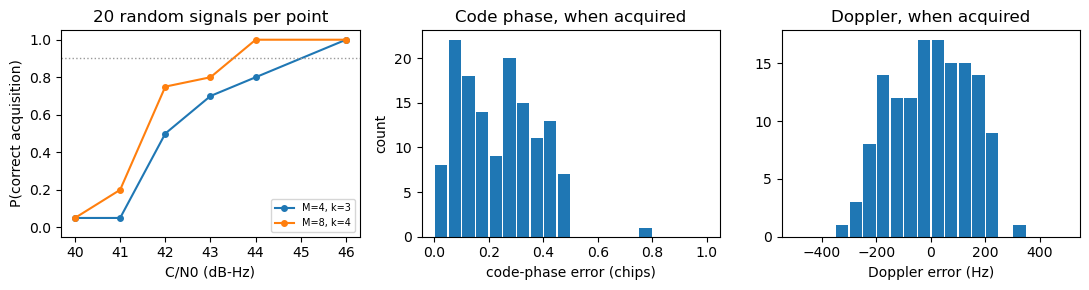

successful acquisitions: 138
  code-phase error : max 0.75 chips, RMS 0.27 chips
  Doppler error    : max 328 Hz,  RMS 143 Hz


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for m in K_OF_M:
    axes[0].plot(CN0S, Pd[m], "o-", ms=4, label=f"M={m}, k={K_OF_M[m]}")
axes[0].axhline(0.9, color="0.6", ls=":", lw=1)
axes[0].set(xlabel="C/N0 (dB-Hz)", ylabel="P(correct acquisition)", ylim=(-0.05, 1.05),
            title=f"{TRIALS} random signals per point")
axes[0].legend(fontsize=7)

good = [v for m in K_OF_M for c in CN0S for v in R[(c, m)] if acquired(v)]
axes[1].hist([v["e_cp"] for v in good], bins=np.linspace(0, 1, 21), rwidth=0.9)
axes[1].set(xlabel="code-phase error (chips)", ylabel="count", title="Code phase, when acquired")
axes[2].hist([v["e_fd"] for v in good], bins=np.linspace(-500, 500, 21), rwidth=0.9)
axes[2].set(xlabel="Doppler error (Hz)", title="Doppler, when acquired")
plt.tight_layout(); plt.show()

e_cp = np.array([v["e_cp"] for v in good]); e_fd = np.array([v["e_fd"] for v in good])
print(f"successful acquisitions: {len(good)}")
print(f"  code-phase error : max {e_cp.max():.2f} chips, RMS {np.sqrt((e_cp**2).mean()):.2f} chips")
print(f"  Doppler error    : max {np.abs(e_fd).max():.0f} Hz,  RMS {np.sqrt((e_fd**2).mean()):.0f} Hz")

In [18]:
print("Outcomes. A trial can declare several cells, so these are not exclusive.\n"
      "'sidelobe' = same satellite and code phase, but a Doppler bin further than one away.\n")
print(f"{'C/N0':>6} {'M':>3} {'acquired':>10} {'no detection':>14} {'sidelobe':>10} {'wrong cell':>12}")
for cn0 in CN0S:
    for m in K_OF_M:
        v = R[(cn0, m)]
        acq  = sum(acquired(x) for x in v)
        none = sum(x["n_declared"] == 0 for x in v)
        sl = sum(x["n_side"] > 0 for x in v)
        fa = sum(x["n_false"] > 0 for x in v)
        print(f"{cn0:>6.0f} {m:>3} {acq/len(v):>10.2f} {none/len(v):>14.2f} "
              f"{sl/len(v):>10.2f} {fa/len(v):>12.2f}")

Outcomes. A trial can declare several cells, so these are not exclusive.
'sidelobe' = same satellite and code phase, but a Doppler bin further than one away.

  C/N0   M   acquired   no detection   sidelobe   wrong cell
    40   4       0.05           0.95       0.00         0.00
    40   8       0.05           0.95       0.00         0.00
    41   4       0.05           0.95       0.00         0.00
    41   8       0.20           0.80       0.00         0.00
    42   4       0.50           0.50       0.00         0.05
    42   8       0.75           0.25       0.00         0.00
    43   4       0.70           0.30       0.00         0.00
    43   8       0.80           0.20       0.00         0.00
    44   4       0.80           0.20       0.00         0.05
    44   8       1.00           0.00       0.00         0.00
    46   4       1.00           0.00       0.05         0.00
    46   8       1.00           0.00       0.20         0.00


Three things to read off these results.

**The transition is sharp and lands where the study says it should.** Accuracy climbs from near
zero to near one over about 3 dB. Notebook 07 sizes this same configuration at 17 dwells for
$P_d = 0.9$ at 38 dB-Hz; here we spend 4–8 dwells, so the curve sits a few dB higher.
Consistent, not contradictory.

**When it succeeds it is accurate, and only as accurate as the grid.** Code phase lands within
half a chip, Doppler within half a bin. That is the *resolution of the search*, not a property
of the signal — the CAM returns a cell index, and tracking refines from there. Which is
precisely why GNSS suits a boolean readout: nobody wanted an estimate, only a starting point.

**When it fails, it mostly fails safe.** Failures are overwhelmingly "no detection" rather than
a wrong cell — the $k$-of-$M$ rule at work. A wrong cell has to get lucky $k$ separate times,
and $k$ was chosen so that is unlikely across all 2.7 M of them. This is measured *without*
ranking: any wrong cell reaching $k$ counts against us even when the true cell also fired.

The `sidelobe` column is worth separating out rather than lumping in with false alarms. Those
are the *same* satellite at the *same* code phase, one or more Doppler bins further out — the
signal itself leaking through the sinc skirt, not an independent error. A receiver hands the
whole cluster to tracking and loses nothing; counting them as false alarms would understate
the design.

The few dB between this curve and an idealized one are paid to realism: the true code phase and
Doppler fall *between* grid points, worth about 3 dB together. A real receiver either accepts
that or searches a finer grid, which costs area.

---
## 12. Cross-check against the repo

Everything above was written from scratch in this notebook. It should agree bit for bit with
`sim/gps/`, which is what the rest of the study measures.

In [19]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from sim.gps import codebook, quantize
from sim.gps.prn import ca_code_bipolar

cb = codebook.build_codebook(prns=PRNS, f_max=10e3, t_coh=1e-3, fs=FS, mapping="sign")
x = np.array([0.3 + 0.2j, -1.1 + 0.4j, 0.5 - 2.0j])
k_repo = quantize.quantize_to_key(x, 1.0, "sign")

print("Gold codes identical :", all(np.array_equal(ca_code(p), ca_code_bipolar(p)) for p in [1, 7, 19, 32]))
print("codebook identical   :", np.array_equal(cb.rows, rows))
print("key mapping identical:", np.array_equal(k_repo.astype(bool), to_key(x)))
print("rotation identical   :", all(np.array_equal(quantize.rotate_key(k_repo, q, "sign").astype(bool),
                                                   rotate(to_key(x), q)) for q in range(4)))

Gold codes identical : True
codebook identical   : True
key mapping identical: True
rotation identical   : True


---
## That's the algorithm

| Step | What it costs |
|---|---|
| Sign-quantize the samples | 1.96 dB — any 1-bit front end pays it |
| One row per (satellite, Doppler) | 5.4 Mbit for a full 32-satellite, ±10 kHz search |
| Slide the key over code phase | one clock per code phase |
| Try 4 carrier rotations | free — exact bit permutations |
| Threshold at $\tau$, count fires | one comparator per row, one counter per cell |

No multipliers, no complex arithmetic, no FFT. Storage and comparators.

### What the rest of the notebooks add

| | |
|---|---|
| **01** | the signal, and why one dwell is never enough at 38 dB-Hz |
| **02** | why 1-bit costs exactly 1.96 dB, and why the rotation is exact |
| **03** | what happens without the rotation sweep (spoiler: nothing works) |
| **04** | the detection-margin formula, verified factor by factor |
| **05** | splitting the match line into segments: 8.2× less memory, at a price |
| **06** | how precisely the sense amplifier must resolve (1 part in 128) |
| **07** | choosing $\tau$ and $k$ properly, and the area-vs-time curve |
| **08** | how this compares to a conventional FFT receiver (+1.9 dB) |

### Try it yourself
- Change `TRUTH` to a different satellite, code phase and Doppler. Does it still find it?
- Lower the C/N0 in §8 to 44, then 40. Where does one dwell stop working?
- Set `GRID = np.array([0.0])` (no Doppler search) and see the true signal vanish.
- Remove the rotation loop in `search` (use `q = 0` only) and watch the algorithm fail completely.